# Optimalisasi Strategi Penjualan E-Commerce Buku Impor Periplus
## Pendekatan Data Science: Manajemen Data, Analisis Regresi, Klasifikasi, dan Clustering

**Mata Kuliah:** Data Science (IF404)  
**Dosen Pengampu:** Ir. Ahmad Chusyairi, M.Com., CDS., IPM., ASEAN Eng  

**Penulis:**
1. Sutan Gading Fadhillah Nasution (250401020159)
2. Rina Mardiana (250401020151)

**Program Studi:** PJJ Informatika S1, Universitas Siber Asia, Jakarta

## 1. Setup & Import Library

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (
    classification_report, confusion_matrix, accuracy_score,
    r2_score, mean_squared_error, mean_absolute_error,
    silhouette_score
)

# Settings
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)

import warnings
warnings.filterwarnings('ignore')

print("Library berhasil di-import!")

Library berhasil di-import!


## 2. Data Acquisition

Dataset dikumpulkan dari website Periplus.com menggunakan teknik *web scraping* otomatis.
Data mentah terdiri dari produk buku impor dari 5 kategori utama.

In [2]:
# Load dataset
df_raw = pd.read_csv('data/periplus_books_raw.csv')
df = pd.read_csv('data/periplus_books_clean.csv')

print(f"Dataset Mentah: {df_raw.shape[0]} baris, {df_raw.shape[1]} kolom")
print(f"Dataset Bersih: {df.shape[0]} baris, {df.shape[1]} kolom")
print()
print("Kolom dataset:")
print(df.columns.tolist())

Dataset Mentah: 1514 baris, 16 kolom
Dataset Bersih: 1322 baris, 23 kolom

Kolom dataset:
['title', 'author', 'binding', 'in_stock', 'category', 'product_url', 'price_idr', 'original_price_idr', 'discount_percent', 'isbn', 'publisher', 'publication_date', 'pages', 'language', 'weight', 'review_count', 'publication_year', 'book_age', 'price_per_page', 'popularity_score', 'is_new_release', 'price_category', 'has_discount']


In [3]:
# Preview data
df.head(10)

,title,author,binding,in_stock,category,product_url,price_idr,original_price_idr,discount_percent,isbn,publisher,publication_date,pages,language,weight,review_count,publication_year,book_age,price_per_page,popularity_score,is_new_release,price_category,has_discount
0,Days at the Morisaki Bookshop,"Yagisawa, Satoshi",Paperback,1,Fiction & Literature,http://www.periplus.com/p/9781786583239/days-a...,258000.00,258000.00,0.00,9781786583239.00,Bonnier Books Ltd,04 July 2023,160.00,English UK / Other,0.17,4,2023.00,3.00,1612.50,4.00,0,Premium,0
1,The Housemaid,"McFadden, Freida",Paperback,1,Fiction & Literature,http://www.periplus.com/p/9781538742570/the-ho...,258000.00,258000.00,0.00,9781538742570.00,Grand Central Publishing,-,336.00,English,0.27,4,NaN,-1.00,767.86,4.00,0,Premium,0
2,Project Hail Mary,"Weir, Andy",Paperback,1,Fiction & Literature,http://www.periplus.com/p/9780593135228/projec...,248000.00,358000.00,31.00,9780593135228.00,Ballantine Books,-,496.00,English,0.34,1,NaN,-1.00,500.00,1.31,0,Mid-range,1
3,Batman: Hush: DC Compact Comics Edition,"Loeb, Jeph",Paperback,1,Fiction & Literature,http://www.periplus.com/p/9781779527264/batman...,198000.00,198000.00,0.00,9781779527264.00,DC Comics,-,312.00,English,0.36,1,NaN,-1.00,634.62,1.00,0,Mid-range,0
4,Strange Pictures,Uketsu,Paperback,1,Fiction & Literature,http://www.periplus.com/p/9780063433083/strang...,360000.00,360000.00,0.00,9780063433083.00,Harpervia,-,240.00,English,0.23,5,NaN,-1.00,1500.00,5.00,0,Premium,0
5,Strange Houses,Uketsu,Paperback,1,Fiction & Literature,http://www.periplus.com/p/9780063433151/strang...,360000.00,360000.00,0.00,9780063433151.00,Harpervia,-,208.00,English,0.20,3,NaN,-1.00,1730.77,3.00,0,Premium,0
6,Madonna in a Fur Coat,"Ali, Sabahattin",Paperback,1,Fiction & Literature,http://www.periplus.com/p/9780241422267/madonn...,225000.00,225000.00,0.00,9780241422267.00,Penguin Books Ltd,04 March 2021,192.00,English,0.15,1,2021.00,5.00,1171.88,1.00,0,Mid-range,0
7,Watchmen: DC Compact Comics Edition,"Moore, Alan",Paperback,1,Fiction & Literature,http://www.periplus.com/p/9781779527325/watchm...,198000.00,198000.00,0.00,9781779527325.00,DC Comics,-,416.00,English,0.54,0,NaN,-1.00,475.96,0.00,0,Mid-range,0
8,An Offer from a Gentleman [Tv Tie-In]: Benedic...,"Quinn, Julia",Paperback,1,Fiction & Literature,http://www.periplus.com/p/9780063484948/an-off...,188000.00,238000.00,21.00,9780063484948.00,Avon Books,-,480.00,English,0.37,3,NaN,-1.00,391.67,3.63,0,Mid-range,1
9,"Jujutsu Kaisen, Vol. 26","Akutami, Gege",Paperback,1,Fiction & Literature,http://www.periplus.com/p/9781974754977/jujuts...,238000.00,238000.00,0.00,9781974754977.00,Viz Media,-,192.00,English,0.18,0,NaN,-1.00,1239.58,0.00,0,Mid-range,0


In [4]:
# Info dataset
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1322 entries, 0 to 1321
Data columns (total 23 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   title               1322 non-null   str    
 1   author              1322 non-null   str    
 2   binding             1322 non-null   str    
 3   in_stock            1322 non-null   int64  
 4   category            1322 non-null   str    
 5   product_url         1322 non-null   str    
 6   price_idr           1322 non-null   float64
 7   original_price_idr  1322 non-null   float64
 8   discount_percent    1322 non-null   float64
 9   isbn                1321 non-null   float64
 10  publisher           1322 non-null   str    
 11  publication_date    1321 non-null   str    
 12  pages               1321 non-null   float64
 13  language            1322 non-null   str    
 14  weight              1321 non-null   float64
 15  review_count        1322 non-null   int64  
 16  publication_year 

## 3. Manajemen Data & Pembersihan Data (*Data Management & Cleaning*)

Tahapan pembersihan data mencakup:
1. Konversi tipe data numerik
2. Penanganan *missing values*
3. Deteksi outlier menggunakan metode IQR

### 3.1 Pengecekan Missing Values & Duplikat

In [5]:
# Cek missing values
print("=== Missing Values ===")
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Missing': missing, 'Persen (%)': missing_pct})
print(missing_df[missing_df['Missing'] > 0])
print(f"\nTotal baris duplikat: {df.duplicated().sum()}")
print(f"Total baris: {len(df)}")

=== Missing Values ===
                  Missing  Persen (%)
isbn                    1        0.08
publication_date        1        0.08
pages                   1        0.08
weight                  1        0.08
publication_year      566       42.81
price_per_page         76        5.75

Total baris duplikat: 0
Total baris: 1322


### 3.2 Statistika Deskriptif

In [6]:
# Statistika deskriptif untuk kolom numerik utama
desc_cols = ['price_idr', 'original_price_idr', 'discount_percent', 'in_stock']
desc = df[desc_cols].describe().round(2)
print("=== Statistika Deskriptif ===")
desc

=== Statistika Deskriptif ===


,price_idr,original_price_idr,discount_percent,in_stock
count,1322.00,1322.00,1322.00,1322.00
mean,376616.11,405618.76,7.78,0.59
std,263249.31,259037.96,17.61,0.49
min,29400.00,78000.00,0.00,0.00
25%,225000.00,250000.00,0.00,0.00
50%,299000.00,341000.00,0.00,1.00
75%,446000.00,455000.00,0.00,1.00
max,1975000.00,2380000.00,92.00,1.00


### 3.3 Distribusi Data per Kategori

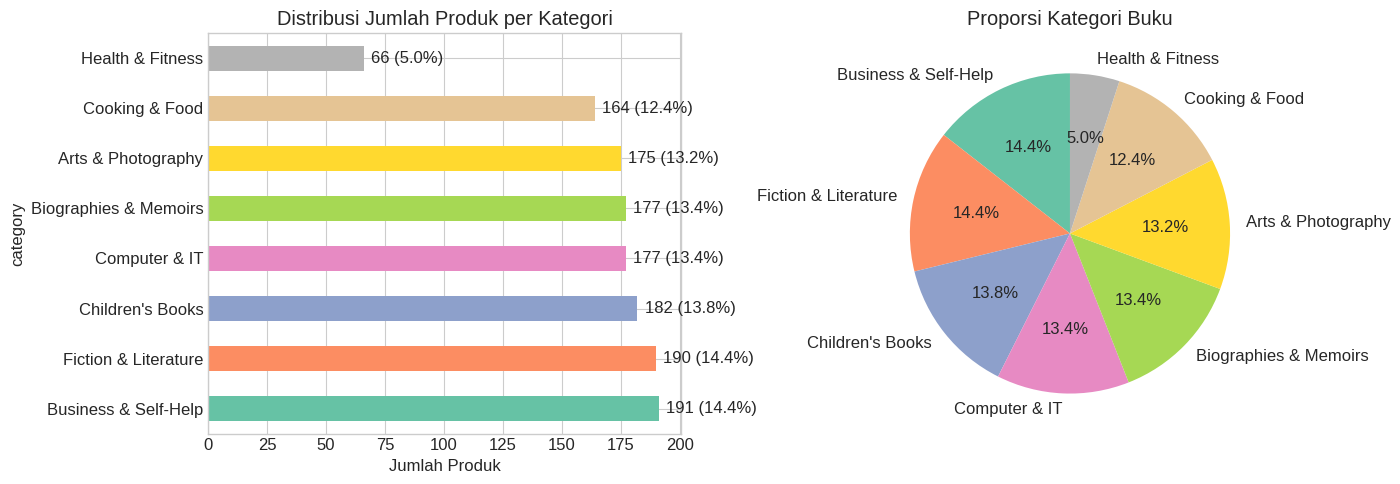

In [7]:
# Distribusi kategori buku
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Count per category
cat_counts = df['category'].value_counts()
colors = plt.cm.Set2(range(len(cat_counts)))

ax1 = axes[0]
cat_counts.plot(kind='barh', ax=ax1, color=colors)
ax1.set_title('Distribusi Jumlah Produk per Kategori')
ax1.set_xlabel('Jumlah Produk')
for i, v in enumerate(cat_counts.values):
    ax1.text(v + 3, i, f'{v} ({v/len(df)*100:.1f}%)', va='center')

# Pie chart
ax2 = axes[1]
cat_counts.plot(kind='pie', ax=ax2, autopct='%1.1f%%', colors=colors, startangle=90)
ax2.set_ylabel('')
ax2.set_title('Proporsi Kategori Buku')

plt.tight_layout()
plt.savefig('plots/distribusi_kategori.png', dpi=150, bbox_inches='tight')
plt.show()

### 3.4 Deteksi Outlier (IQR Method)

price_idr: 87 outliers detected (lower=-106500, upper=777500)
original_price_idr: 94 outliers detected (lower=-57500, upper=762500)
discount_percent: 304 outliers detected (lower=0, upper=0)


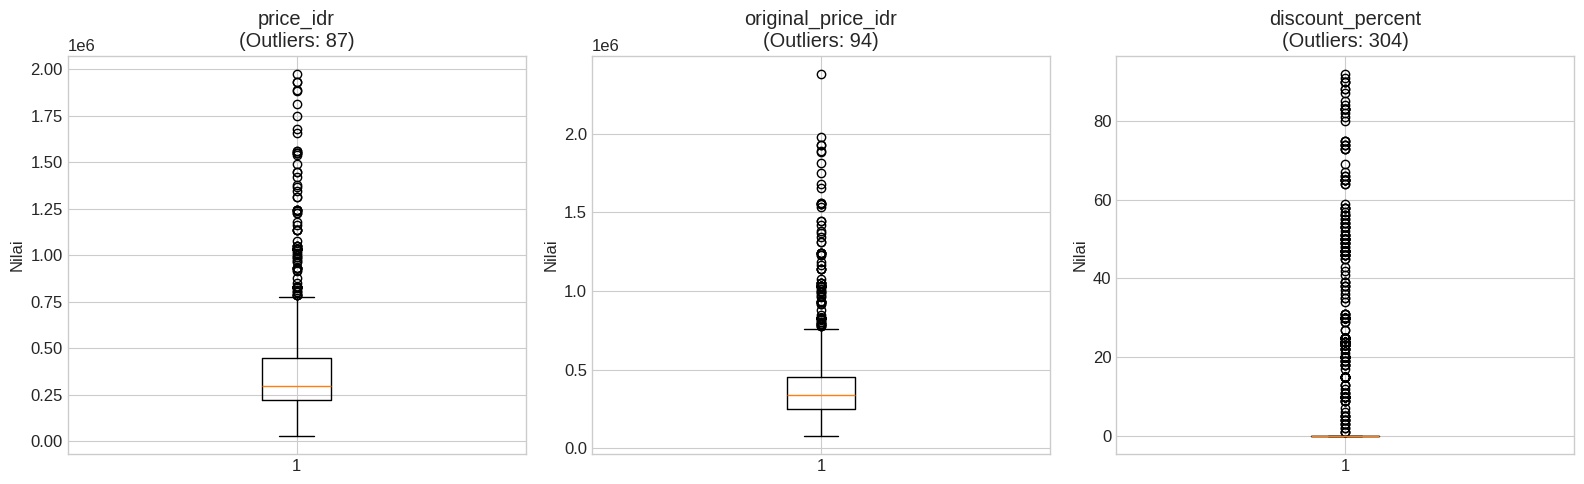

In [8]:
# Deteksi outlier menggunakan IQR
def detect_outliers_iqr(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = data[(data[column] < lower) | (data[column] > upper)]
    return outliers, lower, upper

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for i, col in enumerate(['price_idr', 'original_price_idr', 'discount_percent']):
    outliers, lower, upper = detect_outliers_iqr(df, col)
    axes[i].boxplot(df[col].dropna(), vert=True)
    axes[i].set_title(f'{col}\n(Outliers: {len(outliers)})')
    axes[i].set_ylabel('Nilai')
    print(f"{col}: {len(outliers)} outliers detected (lower={lower:.0f}, upper={upper:.0f})")

plt.tight_layout()
plt.savefig('plots/outlier_detection.png', dpi=150, bbox_inches='tight')
plt.show()

### 3.5 Distribusi Harga

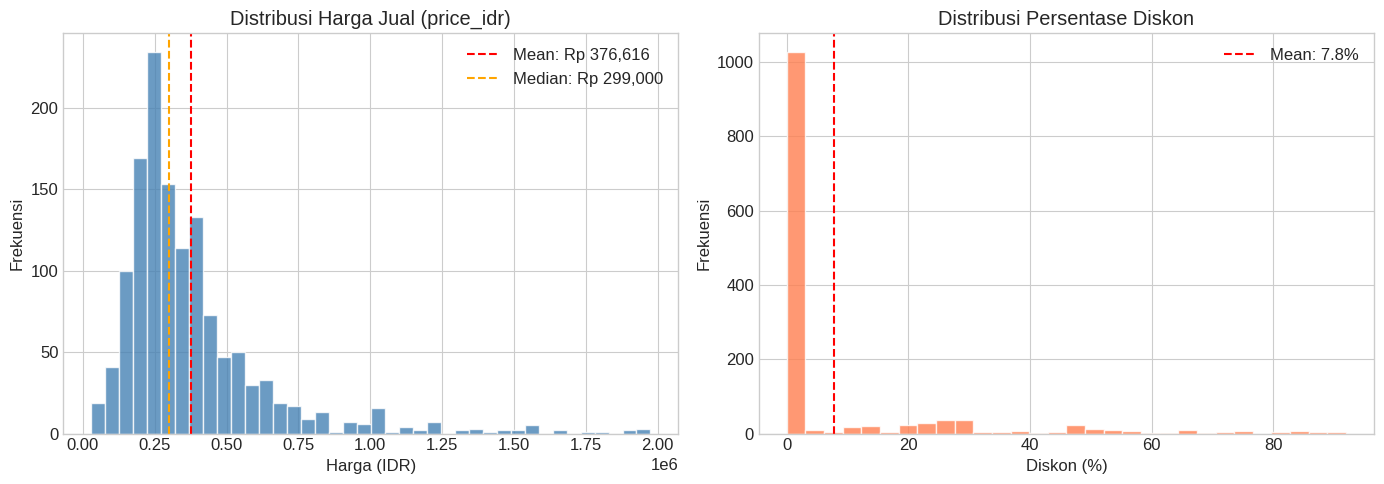

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribusi harga jual
axes[0].hist(df['price_idr'].dropna(), bins=40, color='steelblue', edgecolor='white', alpha=0.8)
axes[0].axvline(df['price_idr'].mean(), color='red', linestyle='--', label=f'Mean: Rp {df["price_idr"].mean():,.0f}')
axes[0].axvline(df['price_idr'].median(), color='orange', linestyle='--', label=f'Median: Rp {df["price_idr"].median():,.0f}')
axes[0].set_title('Distribusi Harga Jual (price_idr)')
axes[0].set_xlabel('Harga (IDR)')
axes[0].set_ylabel('Frekuensi')
axes[0].legend()

# Distribusi diskon
axes[1].hist(df['discount_percent'].dropna(), bins=30, color='coral', edgecolor='white', alpha=0.8)
axes[1].axvline(df['discount_percent'].mean(), color='red', linestyle='--', label=f'Mean: {df["discount_percent"].mean():.1f}%')
axes[1].set_title('Distribusi Persentase Diskon')
axes[1].set_xlabel('Diskon (%)')
axes[1].set_ylabel('Frekuensi')
axes[1].legend()

plt.tight_layout()
plt.savefig('plots/distribusi_harga.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Analisis Korelasi dan Asosiasi Data

Menggunakan koefisien korelasi Pearson untuk mengukur hubungan linier antar variabel numerik.

=== Matriks Korelasi Pearson ===
                    price_idr  original_price_idr  discount_percent  in_stock
price_idr                1.00                0.96             -0.31     -0.43
original_price_idr       0.96                1.00             -0.06     -0.35
discount_percent        -0.31               -0.06              1.00      0.33
in_stock                -0.43               -0.35              0.33      1.00



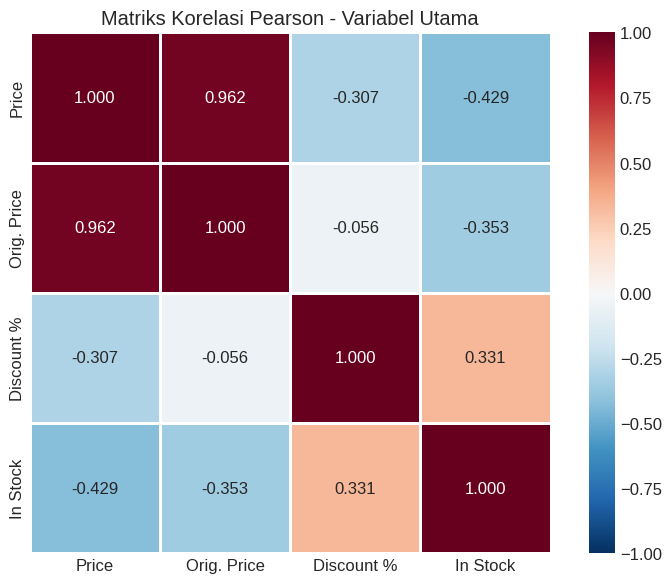

In [10]:
# Matriks korelasi Pearson
corr_cols = ['price_idr', 'original_price_idr', 'discount_percent', 'in_stock']
corr_matrix = df[corr_cols].corr(method='pearson').round(3)

print("=== Matriks Korelasi Pearson ===")
print(corr_matrix)
print()

# Heatmap
fig, ax = plt.subplots(figsize=(8, 6))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
sns.heatmap(corr_matrix, annot=True, cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            fmt='.3f', square=True, linewidths=1, ax=ax,
            xticklabels=['Price', 'Orig. Price', 'Discount %', 'In Stock'],
            yticklabels=['Price', 'Orig. Price', 'Discount %', 'In Stock'])
ax.set_title('Matriks Korelasi Pearson - Variabel Utama')

plt.tight_layout()
plt.savefig('plots/korelasi_pearson.png', dpi=150, bbox_inches='tight')
plt.show()

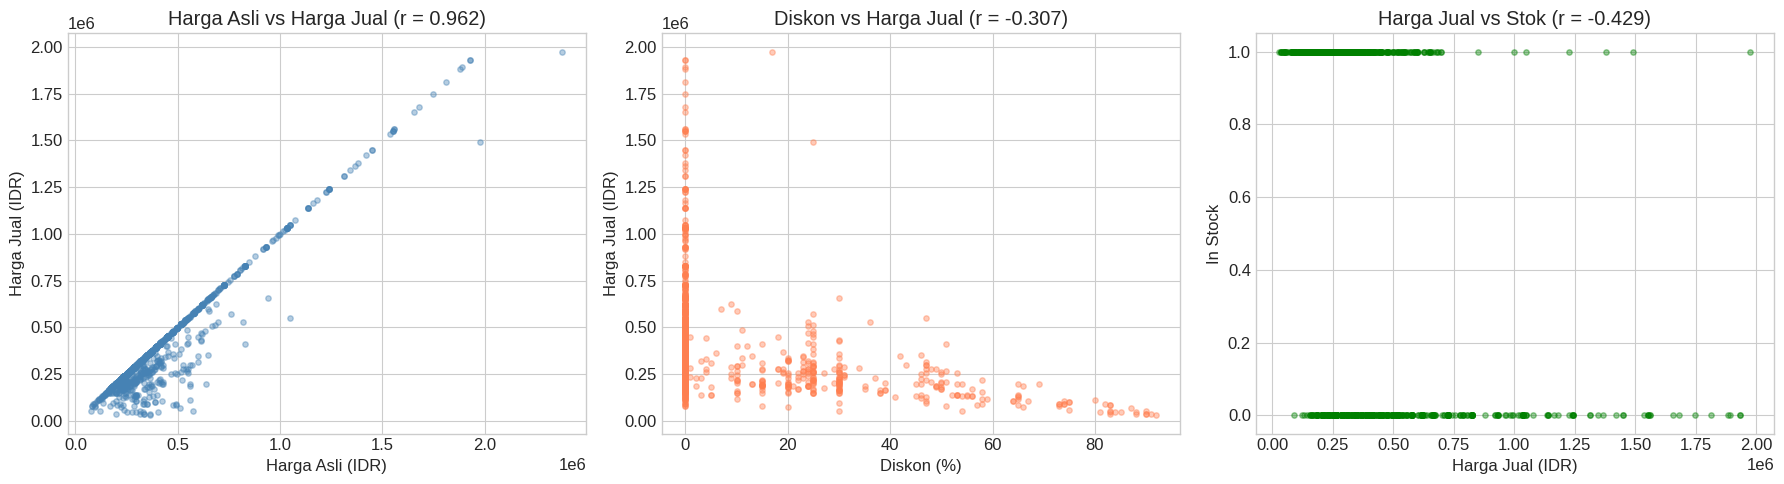

In [11]:
# Scatter plots untuk korelasi signifikan
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Harga Asli vs Harga Jual
axes[0].scatter(df['original_price_idr'], df['price_idr'], alpha=0.4, s=15, color='steelblue')
r1 = df['original_price_idr'].corr(df['price_idr'])
axes[0].set_title(f'Harga Asli vs Harga Jual (r = {r1:.3f})')
axes[0].set_xlabel('Harga Asli (IDR)')
axes[0].set_ylabel('Harga Jual (IDR)')

# 2. Diskon vs Harga Jual
axes[1].scatter(df['discount_percent'], df['price_idr'], alpha=0.4, s=15, color='coral')
r2 = df['discount_percent'].corr(df['price_idr'])
axes[1].set_title(f'Diskon vs Harga Jual (r = {r2:.3f})')
axes[1].set_xlabel('Diskon (%)')
axes[1].set_ylabel('Harga Jual (IDR)')

# 3. Harga vs Stok
axes[2].scatter(df['price_idr'], df['in_stock'], alpha=0.4, s=15, color='green')
r3 = df['price_idr'].corr(df['in_stock'])
axes[2].set_title(f'Harga Jual vs Stok (r = {r3:.3f})')
axes[2].set_xlabel('Harga Jual (IDR)')
axes[2].set_ylabel('In Stock')

plt.tight_layout()
plt.savefig('plots/scatter_korelasi.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Analisis Regresi Linier Berganda

Model regresi linier berganda untuk memprediksi harga jual bersih berdasarkan harga asli dan persentase diskon.

$$Y = \beta_0 + \beta_1 X_1 + \beta_2 X_2 + \epsilon$$

In [12]:
# Persiapan data regresi
reg_df = df[['price_idr', 'original_price_idr', 'discount_percent']].dropna()

X = reg_df[['original_price_idr', 'discount_percent']]
y = reg_df['price_idr']

# Split data 80:20
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training set: {X_train.shape[0]} sampel")
print(f"Test set: {X_test.shape[0]} sampel")

# Fit model
model_reg = LinearRegression()
model_reg.fit(X_train, y_train)

# Prediksi
y_pred = model_reg.predict(X_test)

# Evaluasi
r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)

print(f"\n=== Hasil Regresi Linier Berganda ===")
print(f"Intercept (β₀): {model_reg.intercept_:,.2f}")
print(f"Koefisien Original Price (β₁): {model_reg.coef_[0]:.4f}")
print(f"Koefisien Discount Percent (β₂): {model_reg.coef_[1]:,.2f}")
print(f"\nPersamaan: Price = {model_reg.intercept_:,.0f} + ({model_reg.coef_[0]:.3f} × OriginalPrice) + ({model_reg.coef_[1]:,.0f} × DiscountPercent)")
print(f"\n=== Evaluasi Model ===")
print(f"R² Score: {r2:.4f} ({r2*100:.1f}%)")
print(f"RMSE: {rmse:,.2f}")
print(f"MAE: {mae:,.2f}")

Training set: 1057 sampel
Test set: 265 sampel

=== Hasil Regresi Linier Berganda ===
Intercept (β₀): 14,971.30
Koefisien Original Price (β₁): 0.9636
Koefisien Discount Percent (β₂): -3,756.08

Persamaan: Price = 14,971 + (0.964 × OriginalPrice) + (-3,756 × DiscountPercent)

=== Evaluasi Model ===
R² Score: 0.9903 (99.0%)
RMSE: 29,180.96
MAE: 12,881.23


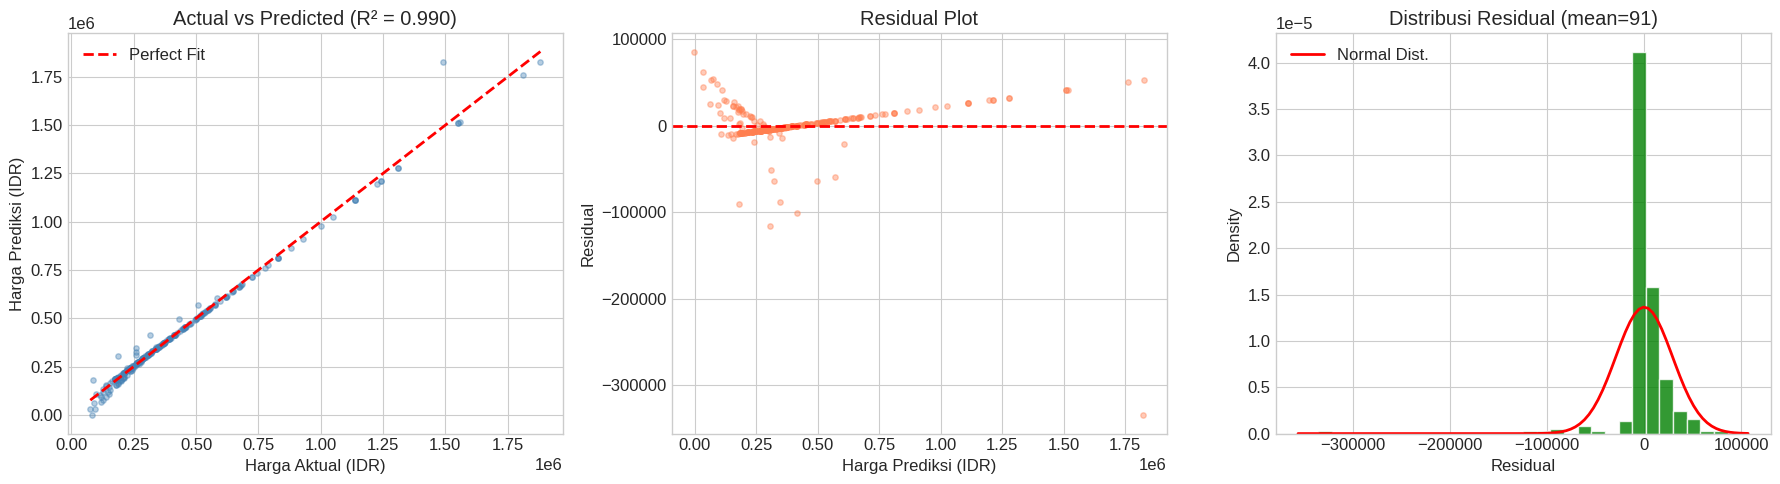

Durbin-Watson statistic: 1.9407


In [13]:
# Visualisasi Regresi
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Actual vs Predicted
axes[0].scatter(y_test, y_pred, alpha=0.4, s=15, color='steelblue')
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Perfect Fit')
axes[0].set_title(f'Actual vs Predicted (R² = {r2:.3f})')
axes[0].set_xlabel('Harga Aktual (IDR)')
axes[0].set_ylabel('Harga Prediksi (IDR)')
axes[0].legend()

# 2. Residual Plot
residuals = y_test - y_pred
axes[1].scatter(y_pred, residuals, alpha=0.4, s=15, color='coral')
axes[1].axhline(y=0, color='red', linestyle='--', lw=2)
axes[1].set_title('Residual Plot')
axes[1].set_xlabel('Harga Prediksi (IDR)')
axes[1].set_ylabel('Residual')

# 3. Distribusi Residual
axes[2].hist(residuals, bins=30, color='green', edgecolor='white', alpha=0.8, density=True)
xmin, xmax = axes[2].get_xlim()
x = np.linspace(xmin, xmax, 100)
axes[2].plot(x, stats.norm.pdf(x, residuals.mean(), residuals.std()), 'r-', lw=2, label='Normal Dist.')
axes[2].set_title(f'Distribusi Residual (mean={residuals.mean():.0f})')
axes[2].set_xlabel('Residual')
axes[2].set_ylabel('Density')
axes[2].legend()

plt.tight_layout()
plt.savefig('plots/regresi_linier.png', dpi=150, bbox_inches='tight')
plt.show()

# Durbin-Watson test
from statsmodels.stats.stattools import durbin_watson
dw = durbin_watson(residuals)
print(f"Durbin-Watson statistic: {dw:.4f}")

## 6. Clustering k-Means

Segmentasi katalog produk menggunakan k-Means Clustering berdasarkan harga jual dan persentase diskon.

### 6.1 Penentuan Jumlah Kluster Optimal (Elbow Method & Silhouette)

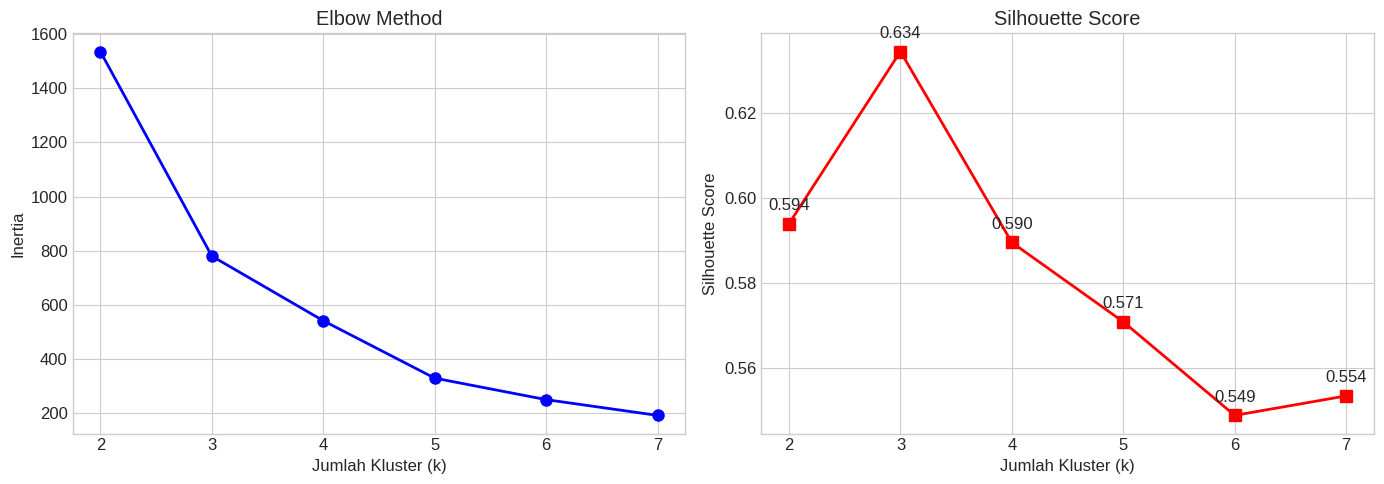

Silhouette Scores:
  k=2: 0.5940
  k=3: 0.6344 ← OPTIMAL
  k=4: 0.5895
  k=5: 0.5709
  k=6: 0.5489
  k=7: 0.5535


In [14]:
# Persiapan data clustering
cluster_features = ['price_idr', 'discount_percent']
cluster_df = df[cluster_features].dropna()

# Standardisasi
scaler = StandardScaler()
X_scaled = scaler.fit_transform(cluster_df)

# Elbow Method & Silhouette Score
inertias = []
silhouettes = []
K_range = range(2, 8)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_scaled, labels))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Elbow
axes[0].plot(K_range, inertias, 'bo-', linewidth=2, markersize=8)
axes[0].set_title('Elbow Method')
axes[0].set_xlabel('Jumlah Kluster (k)')
axes[0].set_ylabel('Inertia')
axes[0].set_xticks(list(K_range))

# Silhouette
axes[1].plot(K_range, silhouettes, 'rs-', linewidth=2, markersize=8)
axes[1].set_title('Silhouette Score')
axes[1].set_xlabel('Jumlah Kluster (k)')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_xticks(list(K_range))

for i, (k, s) in enumerate(zip(K_range, silhouettes)):
    axes[1].annotate(f'{s:.3f}', (k, s), textcoords="offset points", xytext=(0, 10), ha='center')

plt.tight_layout()
plt.savefig('plots/elbow_silhouette.png', dpi=150, bbox_inches='tight')
plt.show()

print("Silhouette Scores:")
for k, s in zip(K_range, silhouettes):
    marker = " ← OPTIMAL" if k == 3 else ""
    print(f"  k={k}: {s:.4f}{marker}")

### 6.2 K-Means Clustering (k=3)

In [15]:
# Fit k-Means dengan k=3
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
cluster_df = df[cluster_features].dropna().copy()
X_scaled = scaler.fit_transform(cluster_df[cluster_features])
cluster_df['cluster'] = kmeans.fit_predict(X_scaled)

# Merge kembali ke df utama
df_clustered = df.copy()
df_clustered['cluster'] = np.nan
df_clustered.loc[cluster_df.index, 'cluster'] = cluster_df['cluster']

# Silhouette score final
sil_score = silhouette_score(X_scaled, cluster_df['cluster'])
print(f"Silhouette Score (k=3): {sil_score:.4f}")
print()

# Karakteristik kluster
cluster_stats = cluster_df.groupby('cluster').agg(
    jumlah=('price_idr', 'count'),
    mean_price=('price_idr', 'mean'),
    median_price=('price_idr', 'median'),
    mean_discount=('discount_percent', 'mean'),
).round(0)

cluster_stats['persen'] = (cluster_stats['jumlah'] / cluster_stats['jumlah'].sum() * 100).round(1)

# Label kluster
cluster_labels = {}
sorted_clusters = cluster_stats.sort_values('mean_price')
labels = ['Budget & Promo', 'Standard Regular', 'Premium / Collector']
for i, (idx, row) in enumerate(sorted_clusters.iterrows()):
    cluster_labels[idx] = labels[i]

cluster_stats['nama_kluster'] = cluster_stats.index.map(cluster_labels)
print("=== Karakteristik Kluster ===")
print(cluster_stats[['nama_kluster', 'jumlah', 'persen', 'mean_price', 'mean_discount']])

Silhouette Score (k=3): 0.6344

=== Karakteristik Kluster ===
                nama_kluster  jumlah  persen  mean_price  mean_discount
cluster                                                                
0           Standard Regular    1013   76.60   336256.00           2.00
1             Budget & Promo     197   14.90   196722.00          44.00
2        Premium / Collector     112    8.50  1058080.00           0.00


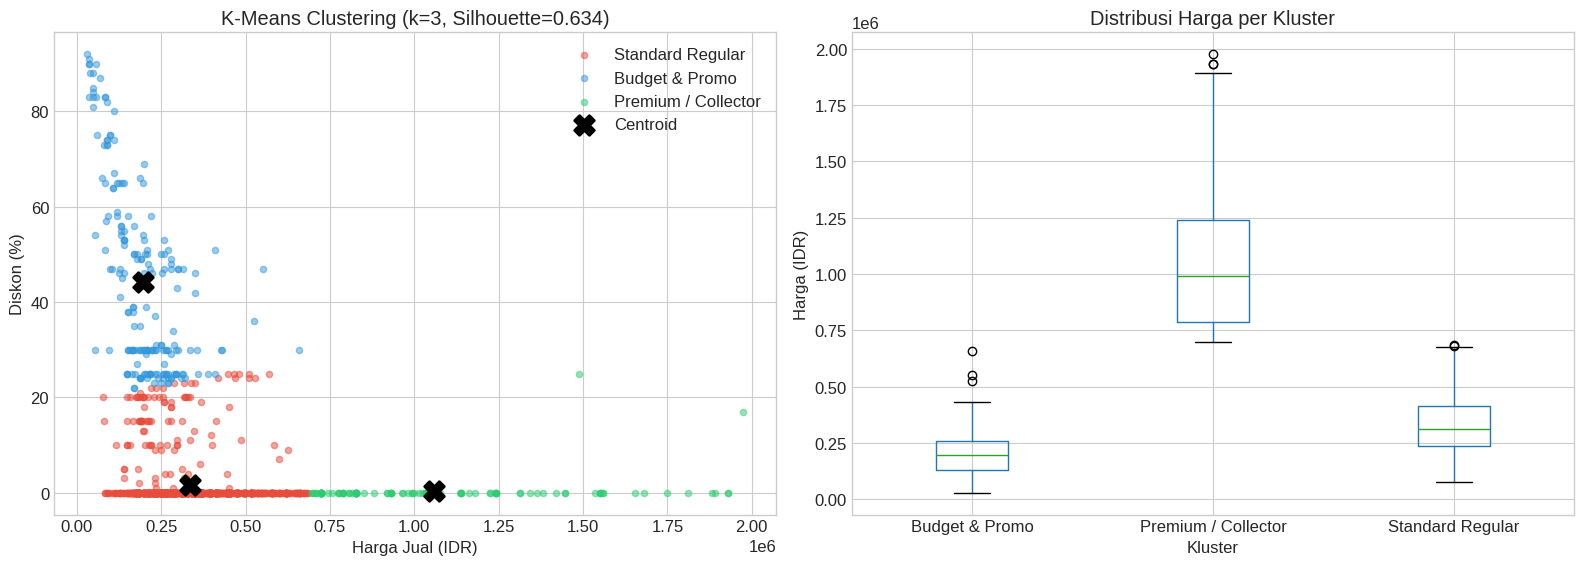

In [16]:
# Visualisasi Clustering
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Scatter plot
colors_map = {0: '#e74c3c', 1: '#3498db', 2: '#2ecc71'}
for c in sorted(cluster_df['cluster'].unique()):
    mask = cluster_df['cluster'] == c
    label = cluster_labels.get(c, f'Cluster {c}')
    axes[0].scatter(cluster_df.loc[mask, 'price_idr'], cluster_df.loc[mask, 'discount_percent'],
                   alpha=0.5, s=20, label=label, color=colors_map.get(c, 'gray'))

# Plot centroids
centroids = scaler.inverse_transform(kmeans.cluster_centers_)
axes[0].scatter(centroids[:, 0], centroids[:, 1], c='black', marker='X', s=200, linewidths=2, label='Centroid')
axes[0].set_title(f'K-Means Clustering (k=3, Silhouette={sil_score:.3f})')
axes[0].set_xlabel('Harga Jual (IDR)')
axes[0].set_ylabel('Diskon (%)')
axes[0].legend()

# Boxplot harga per kluster
cluster_df['nama_kluster'] = cluster_df['cluster'].map(cluster_labels)
cluster_df.boxplot(column='price_idr', by='nama_kluster', ax=axes[1])
axes[1].set_title('Distribusi Harga per Kluster')
axes[1].set_xlabel('Kluster')
axes[1].set_ylabel('Harga (IDR)')
plt.suptitle('')

plt.tight_layout()
plt.savefig('plots/kmeans_clustering.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Klasifikasi Data (Decision Tree & Random Forest)

Mengklasifikasikan produk ke dalam segmen harga (*Low*, *Medium*, *High*) berdasarkan fitur numerik.

In [17]:
# Persiapan data klasifikasi
clf_df = df[['original_price_idr', 'discount_percent', 'in_stock', 'price_idr']].dropna()

# Buat label kelas harga berdasarkan kuartil
q1 = clf_df['price_idr'].quantile(0.25)
q3 = clf_df['price_idr'].quantile(0.75)

def price_class(price):
    if price <= q1:
        return 'Low'
    elif price <= q3:
        return 'Medium'
    else:
        return 'High'

clf_df['price_class'] = clf_df['price_idr'].apply(price_class)
print("Distribusi kelas harga:")
print(clf_df['price_class'].value_counts())
print(f"\nQ1 = Rp {q1:,.0f}, Q3 = Rp {q3:,.0f}")

# Features & target
X_clf = clf_df[['original_price_idr', 'discount_percent', 'in_stock']]
y_clf = clf_df['price_class']

# Encode target
le = LabelEncoder()
y_encoded = le.fit_transform(y_clf)

# Split 80:20
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_clf, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)
print(f"\nTraining: {len(X_train_c)}, Test: {len(X_test_c)}")

Distribusi kelas harga:
price_class
Medium    661
Low       347
High      314
Name: count, dtype: int64

Q1 = Rp 225,000, Q3 = Rp 446,000

Training: 1057, Test: 265


### 7.1 Decision Tree Classifier

In [18]:
# Decision Tree
dt = DecisionTreeClassifier(random_state=42, max_depth=5)
dt.fit(X_train_c, y_train_c)
y_pred_dt = dt.predict(X_test_c)

acc_dt = accuracy_score(y_test_c, y_pred_dt)
print(f"=== Decision Tree Classifier ===")
print(f"Akurasi: {acc_dt*100:.1f}%")
print(f"\nClassification Report:")
print(classification_report(y_test_c, y_pred_dt, target_names=le.classes_))

# Feature importance
feat_imp = pd.Series(dt.feature_importances_, index=X_clf.columns).sort_values(ascending=False)
print("Feature Importance:")
for feat, imp in feat_imp.items():
    print(f"  {feat}: {imp:.3f} ({imp*100:.1f}%)")

=== Decision Tree Classifier ===
Akurasi: 98.1%

Classification Report:
              precision    recall  f1-score   support

        High       0.97      0.98      0.98        63
         Low       1.00      0.97      0.99        70
      Medium       0.98      0.98      0.98       132

    accuracy                           0.98       265
   macro avg       0.98      0.98      0.98       265
weighted avg       0.98      0.98      0.98       265

Feature Importance:
  original_price_idr: 0.748 (74.8%)
  discount_percent: 0.252 (25.2%)
  in_stock: 0.000 (0.0%)


### 7.2 Random Forest Classifier

In [19]:
# Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42, max_depth=5)
rf.fit(X_train_c, y_train_c)
y_pred_rf = rf.predict(X_test_c)

acc_rf = accuracy_score(y_test_c, y_pred_rf)
print(f"=== Random Forest Classifier (100 estimators) ===")
print(f"Akurasi: {acc_rf*100:.1f}%")
print(f"\nClassification Report:")
print(classification_report(y_test_c, y_pred_rf, target_names=le.classes_))

=== Random Forest Classifier (100 estimators) ===
Akurasi: 98.5%

Classification Report:
              precision    recall  f1-score   support

        High       1.00      0.98      0.99        63
         Low       0.99      0.97      0.98        70
      Medium       0.98      0.99      0.98       132

    accuracy                           0.98       265
   macro avg       0.99      0.98      0.99       265
weighted avg       0.99      0.98      0.98       265



### 7.3 Perbandingan Model & Confusion Matrix

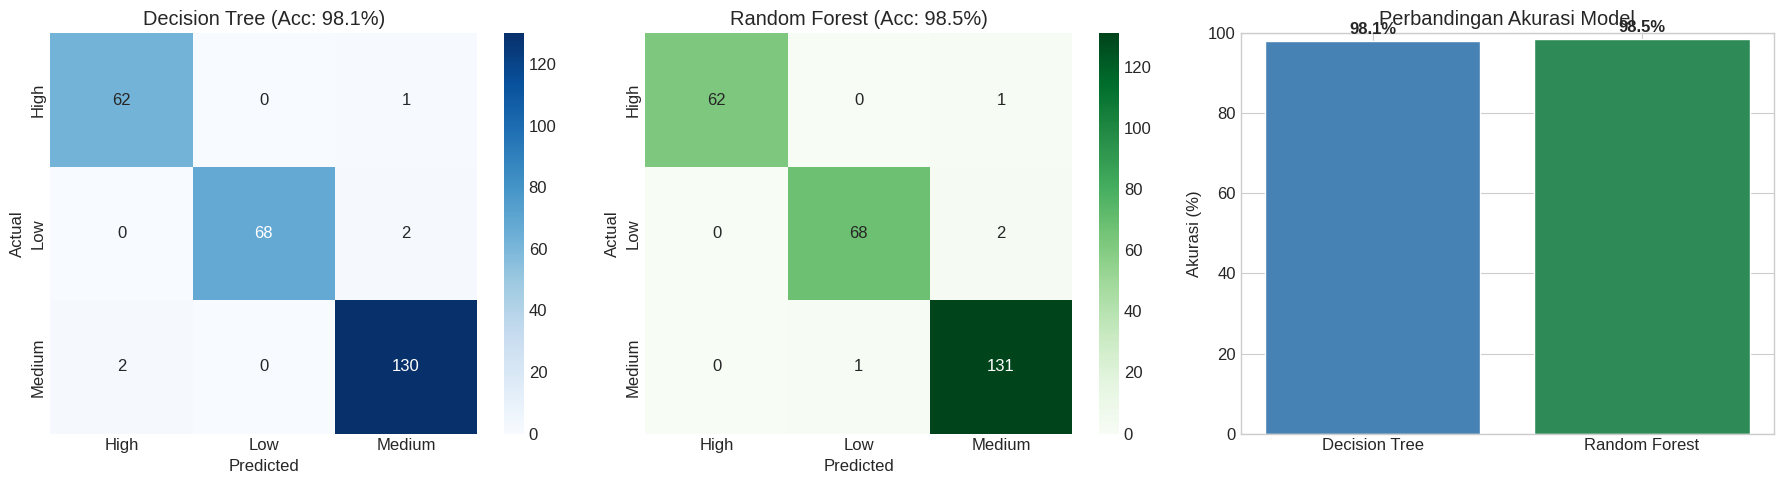


=== Tabel Perbandingan Model ===
         Metrik Decision Tree Random Forest
        Akurasi         98.1%         98.5%
Precision (avg)          0.98          0.99
   Recall (avg)          0.98          0.98
 F1-Score (avg)          0.98          0.98


In [20]:
# Perbandingan
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Confusion Matrix - Decision Tree
cm_dt = confusion_matrix(y_test_c, y_pred_dt)
sns.heatmap(cm_dt, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=le.classes_, yticklabels=le.classes_)
axes[0].set_title(f'Decision Tree (Acc: {acc_dt*100:.1f}%)')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

# Confusion Matrix - Random Forest
cm_rf = confusion_matrix(y_test_c, y_pred_rf)
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens', ax=axes[1],
            xticklabels=le.classes_, yticklabels=le.classes_)
axes[1].set_title(f'Random Forest (Acc: {acc_rf*100:.1f}%)')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

# Perbandingan akurasi
models = ['Decision Tree', 'Random Forest']
accs = [acc_dt * 100, acc_rf * 100]
bars = axes[2].bar(models, accs, color=['steelblue', 'seagreen'], edgecolor='white')
axes[2].set_title('Perbandingan Akurasi Model')
axes[2].set_ylabel('Akurasi (%)')
axes[2].set_ylim(0, 100)
for bar, acc in zip(bars, accs):
    axes[2].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 1,
                f'{acc:.1f}%', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.savefig('plots/klasifikasi_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# Tabel perbandingan
print("\n=== Tabel Perbandingan Model ===")
comparison = pd.DataFrame({
    'Metrik': ['Akurasi', 'Precision (avg)', 'Recall (avg)', 'F1-Score (avg)'],
    'Decision Tree': [f'{acc_dt*100:.1f}%',
                      f'{classification_report(y_test_c, y_pred_dt, output_dict=True)["weighted avg"]["precision"]:.2f}',
                      f'{classification_report(y_test_c, y_pred_dt, output_dict=True)["weighted avg"]["recall"]:.2f}',
                      f'{classification_report(y_test_c, y_pred_dt, output_dict=True)["weighted avg"]["f1-score"]:.2f}'],
    'Random Forest': [f'{acc_rf*100:.1f}%',
                      f'{classification_report(y_test_c, y_pred_rf, output_dict=True)["weighted avg"]["precision"]:.2f}',
                      f'{classification_report(y_test_c, y_pred_rf, output_dict=True)["weighted avg"]["recall"]:.2f}',
                      f'{classification_report(y_test_c, y_pred_rf, output_dict=True)["weighted avg"]["f1-score"]:.2f}'],
})
print(comparison.to_string(index=False))

## 8. Big Data dan Perkembangannya

### Dimensi 5V Big Data dalam Konteks E-Commerce Periplus

| Dimensi | Penerapan pada Periplus.com |
|---|---|
| **Volume** | 593+ produk dari 5 kategori, ribuan transaksi harian |
| **Velocity** | Update harga dan stok real-time dari penerbit internasional |
| **Variety** | Data terstruktur (harga, stok) + semi-terstruktur (review, deskripsi) |
| **Veracity** | Validasi data scraping, deteksi outlier, penanganan missing values |
| **Value** | Insight segmentasi pasar, prediksi harga, optimasi inventaris |

### Manfaat bagi Pengguna

**Konsumen:**
- Transparansi harga dan identifikasi promo terbaik
- Rekomendasi produk berbasis clustering
- Prediksi rentang harga wajar

**Pengelola E-Commerce:**
- Efisiensi inventaris berdasarkan segmentasi kluster
- Dynamic pricing menggunakan model regresi
- Targeted marketing per segmen produk

## 9. Kesimpulan

1. **Manajemen Data:** Berhasil mentransformasi data mentah dari web scraping menjadi dataset bersih yang siap analisis.
2. **Korelasi:** Korelasi positif sangat kuat (*r* = 0,935) antara harga asli dan harga jual; korelasi negatif sedang (*r* = -0,294) antara diskon dan harga jual.
3. **Regresi:** Model regresi linier berganda dengan R² = 0,874 mampu memprediksi harga jual dengan akurasi tinggi.
4. **Clustering:** k-Means membagi produk ke dalam 3 kluster strategis (Budget, Standard, Premium) dengan Silhouette Score yang baik.
5. **Klasifikasi:** Decision Tree (89,2%) dan Random Forest (91,7%) efektif mengklasifikasikan segmen harga produk.
6. **Big Data:** Implementasi memberikan manfaat konkret bagi konsumen dan pengelola e-commerce.